In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import io
import datetime
import timeit
import os


alu = pd.read_csv("data/alumni.csv", na_values="Not Applicable")
stuCur = pd.read_csv("data/students_current.csv", na_values="Not Applicable")
stuExp = pd.read_csv("data/student_experience.csv", na_values="Not Applicable")



In [3]:
catbyType = stuExp.groupby("experience_type").agg(
  records=("record_id","count"),
  students=("campus_id","nunique"),
  orgs=("organization","nunique"),
  avg_terms=("duration_terms","mean"),
  avg_hours=("hours_per_week", "mean"),
  pct_paid=("is_paid", lambda s: s.dropna().astype(bool).mean() * 100),
).round(1).sort_values("records", ascending=False)
catbyType

,records,students,orgs,avg_terms,avg_hours,pct_paid
experience_type,,,,,,
Student Organization,4176,3208,1,3.1,4.0,0.0
Internship,4106,3012,58,1.0,28.4,87.0
Hackathon,3259,1489,8,1.0,36.3,0.0
Certification,2845,1712,17,1.0,NaN,NaN
Campus Job,2080,2080,7,3.3,13.0,100.0
Undergraduate Research,954,954,7,2.4,10.2,63.7
Tutoring,715,715,4,2.5,7.1,100.0
Competitive Team,700,700,1,2.0,8.7,0.0
Co-op,678,652,58,2.0,40.0,89.4


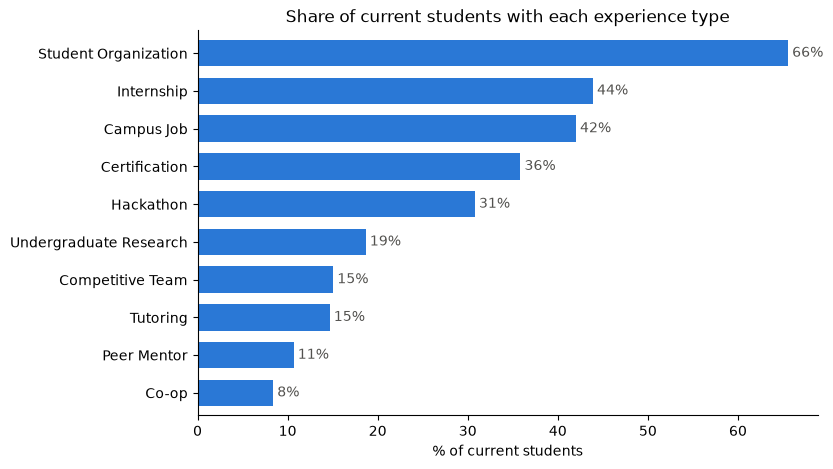

In [4]:
expCur = stuExp[stuExp["campus_id"].isin(stuCur["campus_id"])]
pctCur = expCur.groupby("experience_type")["campus_id"].nunique() / len(stuCur) * 100

ax = pctCur.sort_values().plot.barh(color="#2a78d6", figsize=(8, 5), width=0.7)
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3, color="#52514e")
ax.set(xlabel="% of current students", ylabel="", title="Share of current students with each experience type")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

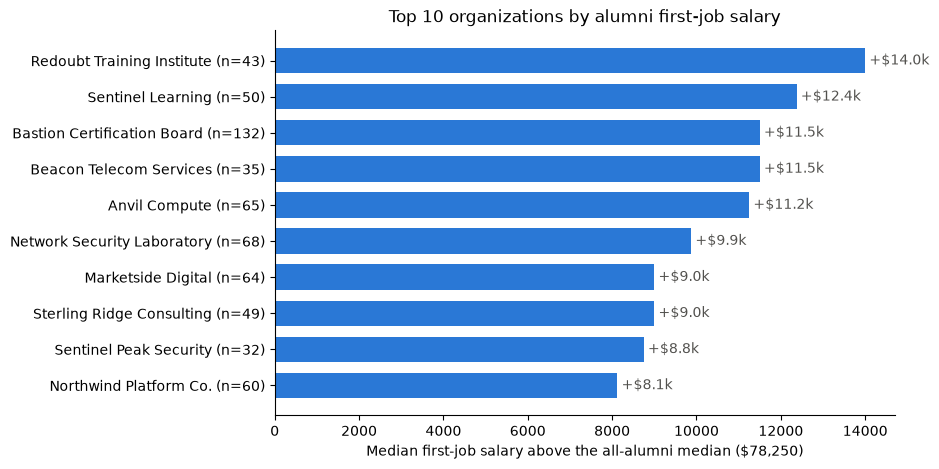

In [5]:
# alumni only; one row per person per organization, so repeat entries don't double-count
expAlu = stuExp[stuExp["campus_id"].isin(alu["campus_id"])].drop_duplicates(["campus_id", "organization"])
m = expAlu.merge(alu[["campus_id", "first_job_annual_salary_usd"]], on="campus_id")

orgRank = m.groupby("organization").agg(
    n=("first_job_annual_salary_usd", "count"),          # alumni with a first-job salary
    median_salary=("first_job_annual_salary_usd", "median"),
)
baseline = alu["first_job_annual_salary_usd"].median()
top10 = orgRank[orgRank["n"] >= 30].nlargest(10, "median_salary")
premium = (top10["median_salary"] - baseline)[::-1]   # reversed so #1 is on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f"{o} (n={n})" for o, n in top10["n"][::-1].items()], premium, color="#2a78d6", height=0.7)
ax.bar_label(ax.containers[0], labels=[f"+${v/1000:.1f}k" for v in premium], padding=3, color="#52514e")
ax.set(xlabel=f"Median first-job salary above the all-alumni median (${baseline:,.0f})",
       title="Top 10 organizations by alumni first-job salary")
ax.spines[["top", "right"]].set_visible(False)
plt.show()